--- First 5 Rows ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.050

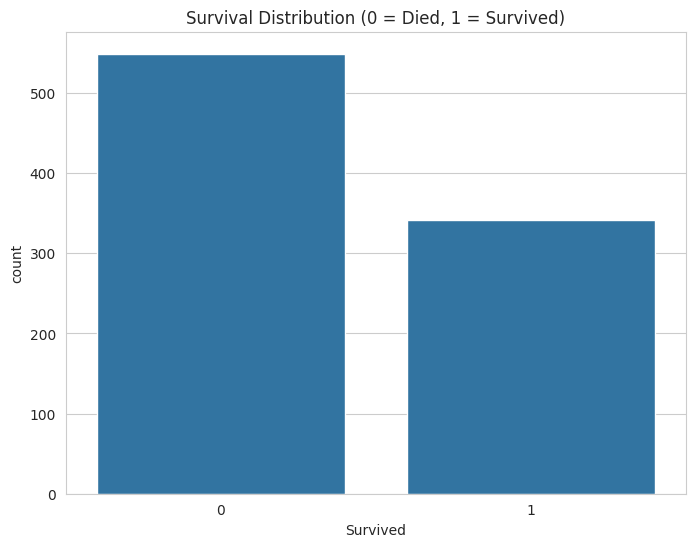

Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.


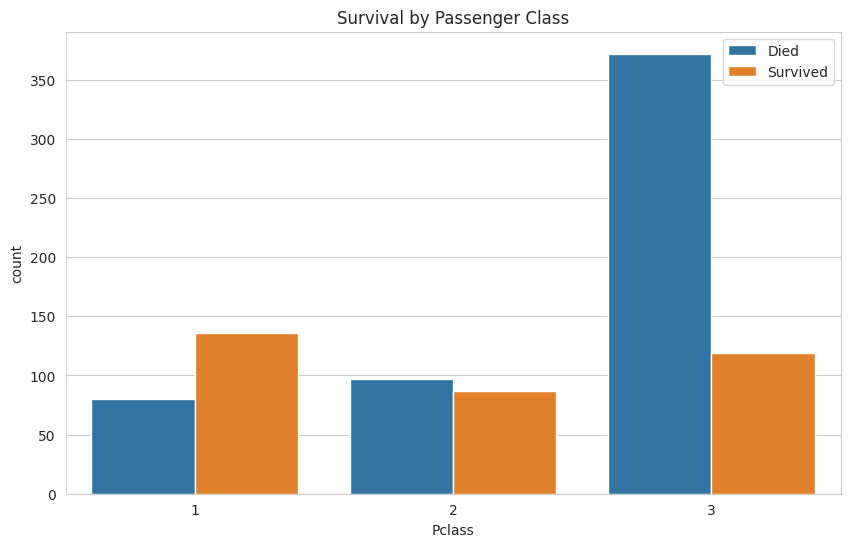

Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Money seems to have made a difference.


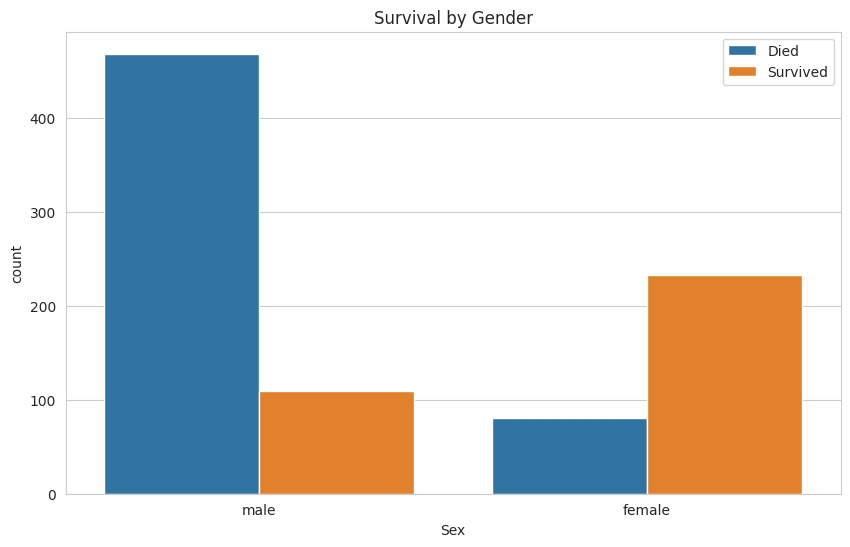

Insight: The pattern is undeniable. A much higher proportion of females survived compared to males. This is another very strong predictor.


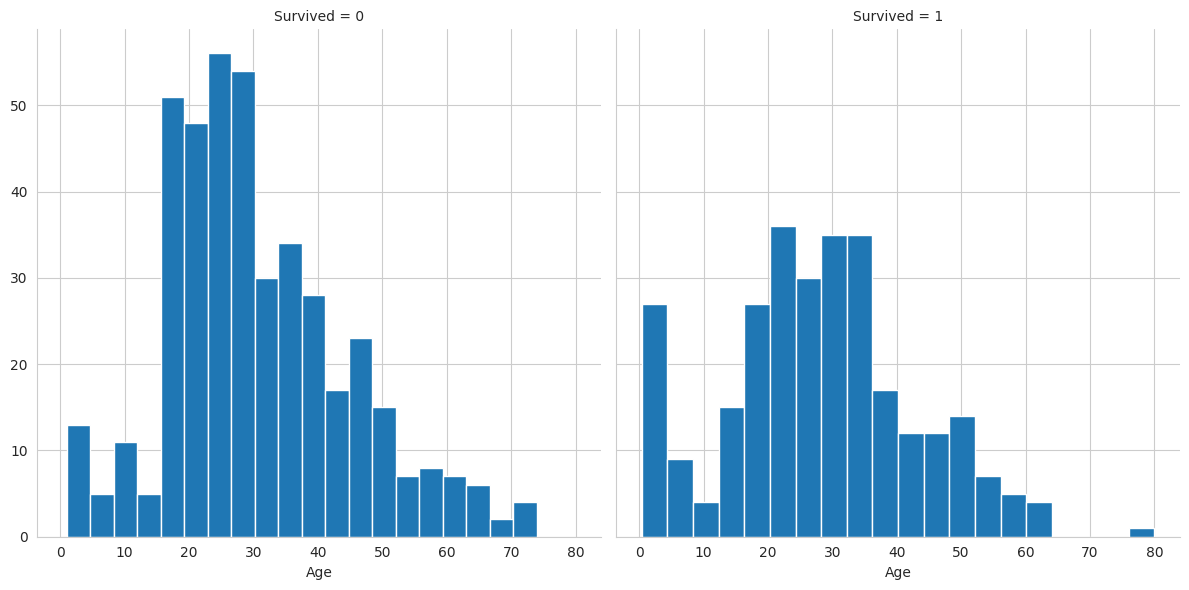

Insight: The age distribution for those who did not survive is centered around the 20-40 age range. For those who survived, there is a noticeable spike for young children. This supports the 'children' part of the mantra.


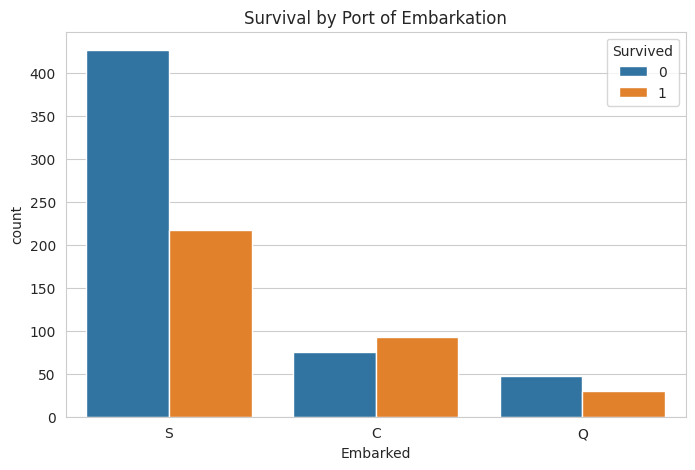

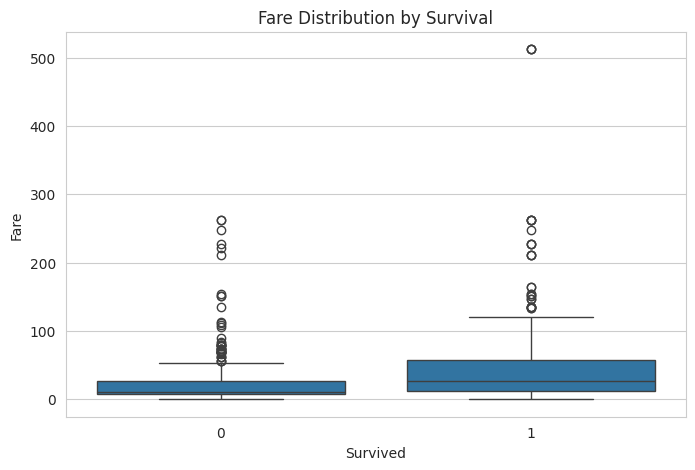

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn is a library built on top of Matplotlib that makes creating beautiful plots easier.

# Load the dataset directly from a URL
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("--- First 5 Rows ---")
print(df.head())

print("--- Basic Info ---")
# .info() is a great first command. It tells us the column names, how many non-null values are in each column, and their data types.
# Notice that 'Age' and 'Cabin' have missing values!
df.info()

# Get summary statistics for numerical columns
print("--- Descriptive Statistics ---")
print(df.describe())

print("--- Key Insights from Statistics ---")
print(f"The average age of a passenger was {df['Age'].mean():.1f} years.")
print(f"The overall survival rate was {df['Survived'].mean():.1%}.")
print(f"Fares ranged from ${df['Fare'].min()} to a whopping ${df['Fare'].max()}.")

sns.set_style('whitegrid') # Sets a nice visual style for our plots
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution (0 = Died, 1 = Survived)')
plt.show()

print("Insight: Far more people died than survived. This is an example of an imbalanced dataset, which can sometimes be a challenge for machine learning models.")

plt.figure(figsize=(10, 6))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.legend(['Died', 'Survived'])
plt.show()

print("Insight: This is a very strong pattern. 1st class passengers had a much higher chance of survival compared to 3rd class passengers. Money seems to have made a difference.")

plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.legend(['Died', 'Survived'])
plt.show()

print("Insight: The pattern is undeniable. A much higher proportion of females survived compared to males. This is another very strong predictor.")

# A FacetGrid allows us to create multiple plots side-by-side to compare distributions.
# Here, we create one histogram for passengers who died (col='Survived'=0) and one for those who survived (col='Survived'=1).
g = sns.FacetGrid(df, col='Survived', height=6)
g.map(plt.hist, 'Age', bins=20)
plt.show()

print("Insight: The age distribution for those who did not survive is centered around the 20-40 age range. For those who survived, there is a noticeable spike for young children. This supports the 'children' part of the mantra.")

#Experiment 1

plt.figure(figsize=(8,5))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Survival by Port of Embarkation')
plt.show()

#Experiment 2

plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival')
plt.show()